# 04 · Phase 3 results: the sealed test years

Every number here comes from 2020-2023, which no model saw during development. The rules (primary
metric, primary candidate, what counts as a win) were fixed in
[`docs/phase3_protocol.md`](../docs/phase3_protocol.md) and pushed to GitHub before these results
existed.

Each neural model is retrained every year with the frozen Fold 1 settings (walk-forward), using seeds
0, 1 and 2. A model's seeds are combined with one third of capital in each seed's book. The tables
come from `scripts/run_backtest.py`; this notebook reads them and adds the charts.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

from sharpee.config import load_config, repo_path
from sharpee.evaluation.walk_forward import make_folds, split
from sharpee.models import build_model
from sharpee.pipeline import load_panel, runs_dir
from sharpee.strategies.ou_strategy import ou_fit
from sharpee.training.dataset import DayBlocks

plt.rcParams.update({"figure.figsize": (9, 3.5), "axes.grid": True, "grid.alpha": 0.3})
FIGURES = repo_path("reports/figures")


def save(fig, name):
    """Keep a copy in reports/figures for the write-up."""
    fig.savefig(FIGURES / f"{name}.png", dpi=120, bbox_inches="tight")


cfg = load_config("data", "experiment", "baseline")
runs = runs_dir(cfg)
phase3 = repo_path(cfg["reports_dir"]) / "phase3"
summary = pd.read_csv(phase3 / "test_summary.csv")
per_year = pd.read_csv(phase3 / "test_per_year.csv")
per_seed = pd.read_csv(phase3 / "test_per_seed.csv")
sig = pd.read_csv(phase3 / "test_significance.csv").set_index("strategy")
daily = pd.read_parquet(phase3 / "test_daily.parquet")

ORDER = ["ou", "mlp", "temporal_cnn", "transformer", "transformer_nocost"]
NAMES = {"ou": "OU", "mlp": "MLP", "temporal_cnn": "Temporal CNN", "transformer": "Transformer",
         "transformer_nocost": "Transformer, no costs in loss"}
COLORS = {"ou": "tab:gray", "mlp": "tab:blue", "temporal_cnn": "tab:orange", "transformer": "tab:green",
          "transformer_nocost": "tab:olive"}
MAIN = [s for s in ORDER[:4] if s in sig.index]
print(f"strategies: {', '.join(NAMES[s] for s in sig.index)}; "
      f"{daily.index[0].date()} to {daily.index[-1].date()} ({len(daily)} days)")

strategies: OU, MLP, Temporal CNN, Transformer, Transformer, no costs in loss; 2020-01-02 to 2023-12-29 (1006 days)


## 1. The verdict

In [2]:
display(Markdown((phase3 / "test_verdict.md").read_text(encoding="utf-8")))

# Phase 3 verdict (test, 2020-2023)

Primary candidate: Transformer, seeds combined, net of 5 bps.

- Net Sharpe +0.17 (95% CI -0.72 to +1.08)
- Rule 1, PSR = 0.636 (needs >= 0.95): fail
- Rule 2, DSR = 0.240 with N = 15 (needs >= 0.95): fail
- Rule 3, Sharpe vs OU +0.03 (95% CI -0.84 to +0.98, must exclude 0): fail

**Verdict: no reliable edge after costs.**


## 2. Headline results

Net of 5 bps, seeds combined. PSR is the probability that the true Sharpe is above zero. DSR is the same
probability with the bar raised for the 15 configurations tried in Phase 2. The confidence interval is
a stationary bootstrap that keeps the serial correlation of daily returns.

In [3]:
main = summary[(summary["cost_bps"] == cfg["cost_bps"]) & (summary["delay"] == 0)].set_index("strategy")
table = pd.DataFrame({
    "ann. return": main["ann_return"], "ann. vol": main["ann_vol"], "net Sharpe": main["sharpe"],
    "95% CI": [f"{sig.loc[s, 'ci_low']:+.2f} to {sig.loc[s, 'ci_high']:+.2f}" for s in main.index],
    "gross Sharpe": main["gross_sharpe"], "max drawdown": main["max_drawdown"],
    "turnover / day": main["avg_turnover"], "beta": main["beta"],
    "PSR": sig.loc[main.index, "psr"], "DSR": sig.loc[main.index, "dsr"],
}).loc[[s for s in ORDER if s in main.index]].rename(index=NAMES)
table.round(3)

,ann. return,ann. vol,net Sharpe,95% CI,gross Sharpe,max drawdown,turnover / day,beta,PSR,DSR
strategy,,,,,,,,,,
OU,0.006,0.038,0.147,-0.98 to +1.22,0.940,-0.080,0.238,0.047,0.616,0.225
MLP,0.010,0.061,0.156,-0.79 to +1.01,0.546,-0.122,0.190,0.075,0.623,0.230
Temporal CNN,-0.007,0.057,-0.122,-1.10 to +0.71,0.339,-0.116,0.208,0.063,0.404,0.101
Transformer,0.010,0.059,0.172,-0.72 to +1.08,0.508,-0.124,0.156,0.066,0.636,0.240
"Transformer, no costs in loss",-0.005,0.060,-0.079,-1.02 to +0.73,0.418,-0.120,0.237,0.071,0.438,0.115


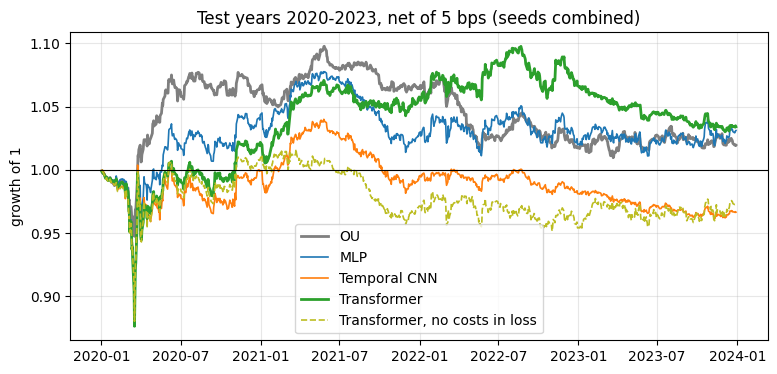

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for s in [s for s in ORDER if s in sig.index]:
    eq = (1 + daily[s]["net"]).cumprod()
    ax.plot(eq.index, eq.values, color=COLORS[s], lw=2 if s in ("ou", "transformer") else 1.2,
            ls="--" if s == "transformer_nocost" else "-", label=NAMES[s])
ax.axhline(1, color="black", lw=0.8)
ax.set_ylabel("growth of 1")
ax.set_title("Test years 2020-2023, net of 5 bps (seeds combined)")
ax.legend()
save(fig, "04_test_equity")
plt.show()

The pre-registered verdict for the Transformer is **no reliable edge after costs**: net Sharpe +0.17 against OU's +0.15, with a 95% interval of -0.72 to +1.08. Four years of daily data can't separate Sharpe ratios this close. Every strategy fell in the March 2020 crash; OU recovered fastest, while the Transformer led from mid-2021 to late 2022 and then gave ground back in 2023.

## 3. Year by year

One aggregate Sharpe can hide a strategy that only worked in one year. 2020 (the COVID crash and
rebound) and 2022 (the rate-hike bear market) are very different regimes.

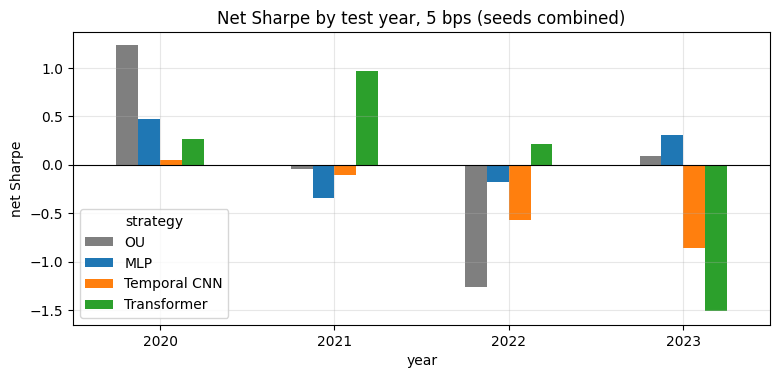

strategy,OU,MLP,Temporal CNN,Transformer
year,,,,
2020,1.23,0.48,0.05,0.26
2021,-0.05,-0.35,-0.11,0.96
2022,-1.26,-0.17,-0.57,0.21
2023,0.09,0.31,-0.86,-1.52


In [5]:
py = per_year[per_year["strategy"].isin(MAIN)].pivot(index="year", columns="strategy", values="sharpe")[MAIN]
ax = py.rename(columns=NAMES).plot.bar(rot=0, color=[COLORS[s] for s in MAIN], figsize=(9, 3.8))
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("net Sharpe")
ax.set_title("Net Sharpe by test year, 5 bps (seeds combined)")
save(ax.figure, "04_sharpe_by_year")
plt.show()
py.rename(columns=NAMES).round(2)

## 4. Costs and execution delay

Each strategy's net Sharpe across cost levels, and the effect of trading one day late (weights formed at
*t* earning *t+1 → t+2*).

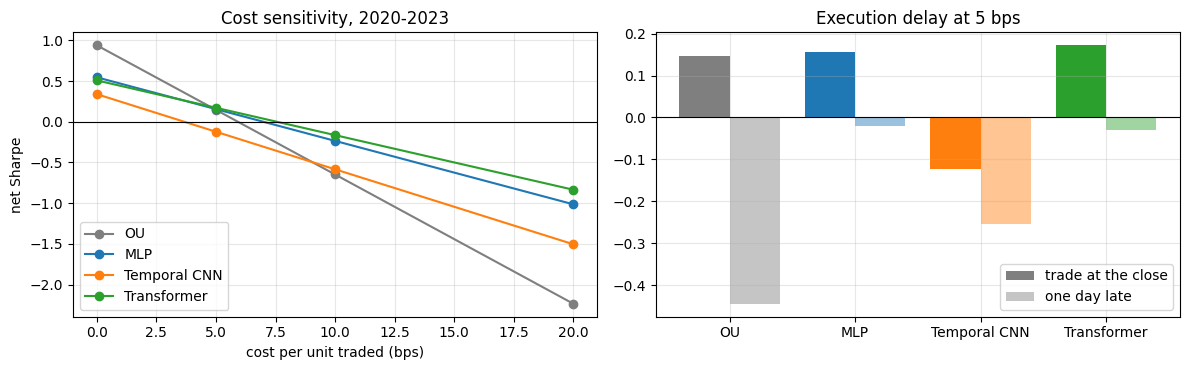

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
nodelay = summary[summary["delay"] == 0]
for s in MAIN:
    c = nodelay[nodelay["strategy"] == s]
    axes[0].plot(c["cost_bps"], c["sharpe"], marker="o", color=COLORS[s], label=NAMES[s])
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xlabel("cost per unit traded (bps)")
axes[0].set_ylabel("net Sharpe")
axes[0].set_title("Cost sensitivity, 2020-2023")
axes[0].legend()
at5 = summary[summary["cost_bps"] == cfg["cost_bps"]].pivot(index="strategy", columns="delay", values="sharpe").loc[MAIN]
x = np.arange(len(MAIN))
axes[1].bar(x - 0.2, at5[0], width=0.4, color=[COLORS[s] for s in MAIN], label="trade at the close")
axes[1].bar(x + 0.2, at5[1], width=0.4, color=[COLORS[s] for s in MAIN], alpha=0.45, label="one day late")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(x, [NAMES[s] for s in MAIN])
axes[1].set_title("Execution delay at 5 bps")
axes[1].legend()
fig.tight_layout()
save(fig, "04_cost_and_delay")
plt.show()

## 5. Ablation: does training on costs matter?

The project's central claim is that putting costs inside the training loss teaches the model to trade
less where trading doesn't pay. To test it, the same Transformer (same architecture, settings, seeds and
folds) was retrained with `train_cost_bps = 0`, then both versions were evaluated at 5 bps.

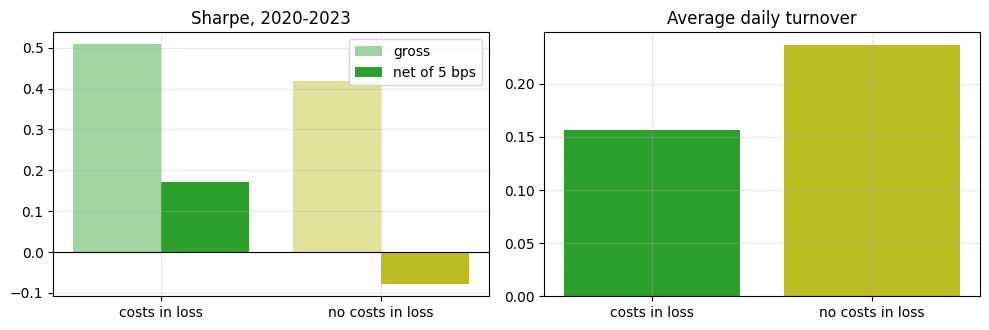

,gross Sharpe,net Sharpe,turnover / day,cost drag / yr
strategy,,,,
Transformer,0.508,0.172,0.156,0.02
"Transformer, no costs in loss",0.418,-0.079,0.237,0.03


In [7]:
pair = [s for s in ["transformer", "transformer_nocost"] if s in main.index]
abl = pd.DataFrame({"gross Sharpe": main.loc[pair, "gross_sharpe"], "net Sharpe": main.loc[pair, "sharpe"],
                    "turnover / day": main.loc[pair, "avg_turnover"],
                    "cost drag / yr": main.loc[pair, "cost_drag"]}).rename(index=NAMES)
if len(pair) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    cols = [COLORS[s] for s in pair]
    axes[0].bar(np.arange(2) - 0.2, abl["gross Sharpe"], width=0.4, color=cols, alpha=0.45, label="gross")
    axes[0].bar(np.arange(2) + 0.2, abl["net Sharpe"], width=0.4, color=cols, label="net of 5 bps")
    axes[0].axhline(0, color="black", lw=0.8)
    axes[0].set_xticks(np.arange(2), ["costs in loss", "no costs in loss"])
    axes[0].set_title("Sharpe, 2020-2023")
    axes[0].legend()
    axes[1].bar(np.arange(2), abl["turnover / day"], color=cols)
    axes[1].set_xticks(np.arange(2), ["costs in loss", "no costs in loss"])
    axes[1].set_title("Average daily turnover")
    fig.tight_layout()
    save(fig, "04_ablation_costs")
    plt.show()
abl.round(3)

Training with costs in the loss helped in **every seed**. Net Sharpe at 5 bps was higher in all three (-0.16 vs -0.23, +0.34 vs -0.02, +0.31 vs +0.02), and turnover was lower in all three (15.6% vs 23.7% of the book per day on average). Combined, that is +0.17 against -0.08. Gross Sharpe was higher too (0.51 vs 0.42), so the model didn't just trade less: what it traded was better. This is the clearest result of Phase 3, and it supports the project's central design choice, although it isn't a formal significance test.

## 6. How sure can we be?

Each strategy's net Sharpe with its 95% bootstrap interval, and the paired difference against OU (the
same resampled days for both, so their correlation is kept).

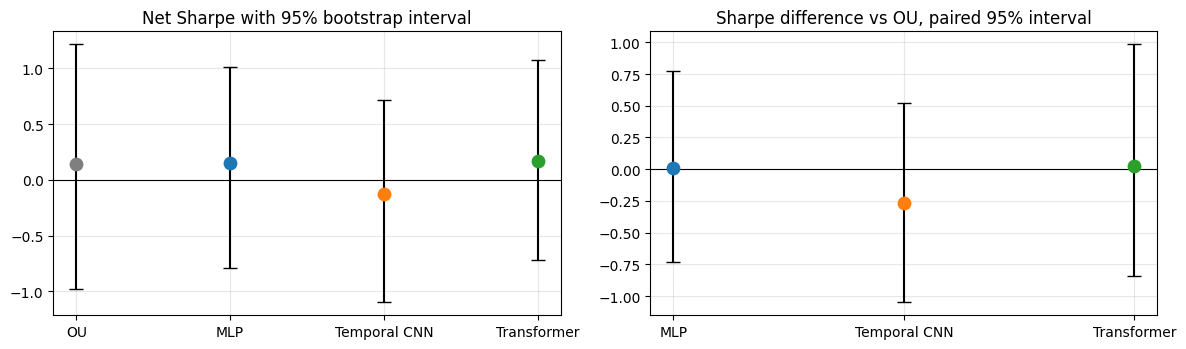

,net_sharpe,ci_low,ci_high,psr,dsr,diff_vs_ou,diff_ci_low,diff_ci_high
strategy,,,,,,,,
OU,0.147,-0.982,1.216,0.616,0.225,NaN,NaN,NaN
MLP,0.156,-0.789,1.009,0.623,0.230,0.009,-0.735,0.773
Temporal CNN,-0.122,-1.098,0.714,0.404,0.101,-0.269,-1.050,0.523
Transformer,0.172,-0.715,1.075,0.636,0.240,0.025,-0.839,0.985
"Transformer, no costs in loss",-0.079,-1.018,0.733,0.438,0.115,-0.226,-1.045,0.623


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
x = np.arange(len(MAIN))
s_ = sig.loc[MAIN]
axes[0].errorbar(x, s_["net_sharpe"], yerr=[s_["net_sharpe"] - s_["ci_low"], s_["ci_high"] - s_["net_sharpe"]],
                 fmt="o", capsize=5, color="black")
for i, s in enumerate(MAIN):
    axes[0].scatter([i], [s_.loc[s, "net_sharpe"]], color=COLORS[s], s=80, zorder=3)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(x, [NAMES[s] for s in MAIN])
axes[0].set_title("Net Sharpe with 95% bootstrap interval")
models = [s for s in MAIN if s != "ou"]
d = sig.loc[models]
xm = np.arange(len(models))
axes[1].errorbar(xm, d["diff_vs_ou"], yerr=[d["diff_vs_ou"] - d["diff_ci_low"], d["diff_ci_high"] - d["diff_vs_ou"]],
                 fmt="o", capsize=5, color="black")
for i, s in enumerate(models):
    axes[1].scatter([i], [d.loc[s, "diff_vs_ou"]], color=COLORS[s], s=80, zorder=3)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xticks(xm, [NAMES[s] for s in models])
axes[1].set_title("Sharpe difference vs OU, paired 95% interval")
fig.tight_layout()
save(fig, "04_sharpe_intervals")
plt.show()
sig.loc[[s for s in ORDER if s in sig.index], ["net_sharpe", "ci_low", "ci_high", "psr", "dsr",
                                                "diff_vs_ou", "diff_ci_low", "diff_ci_high"]].rename(index=NAMES).round(3)

## 7. Does the learned rule hold out of sample?

On validation, all three networks learned to revert moderate residual moves and follow extreme ones.
Here is the same check on the test years, using each model's seed-0 walk-forward scores.

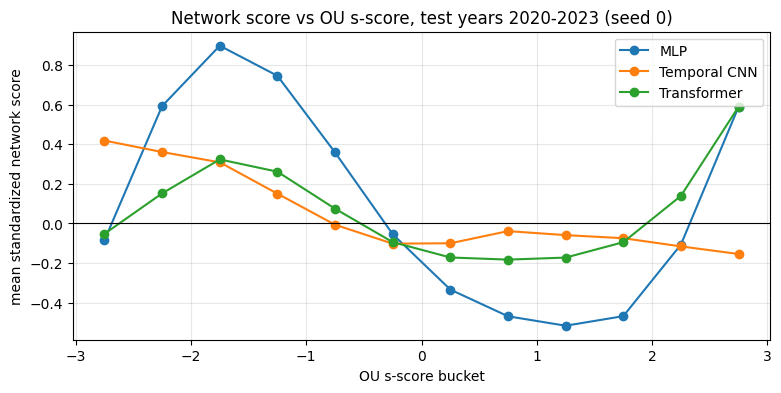

In [9]:
panel = load_panel(cfg)
test_idx = panel.index_of(f"{cfg['test_years'][0]}-01-01", f"{cfg['test_years'][-1]}-12-31")
s_test, _, ok = ou_fit(panel.windows(test_idx, cfg["window"]))
ok &= panel.tradable[test_idx]
edges = np.arange(-3, 3.01, 0.5)
mid = (edges[:-1] + edges[1:]) / 2

fig, ax = plt.subplots(figsize=(9, 4))
for name in ["mlp", "temporal_cnn", "transformer"]:
    sc = np.load(runs / "walkforward" / "test" / f"{name}_seed0.npz")["scores"].astype(np.float64)
    sc = np.where(panel.tradable[test_idx], sc, np.nan)
    z = (sc - np.nanmean(sc, axis=1, keepdims=True)) / np.nanstd(sc, axis=1, keepdims=True)
    b = np.digitize(s_test[ok], edges) - 1
    keep = (b >= 0) & (b < len(mid))
    curve = pd.Series(z[ok][keep]).groupby(b[keep]).mean()
    ax.plot(mid[curve.index], curve.values, marker="o", color=COLORS[name], label=NAMES[name])
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("OU s-score bucket")
ax.set_ylabel("mean standardized network score")
ax.set_title("Network score vs OU s-score, test years 2020-2023 (seed 0)")
ax.legend()
save(fig, "04_score_vs_sscore_test")
plt.show()

The validation pattern largely survives out of sample. The MLP and Transformer still revert moderate stretches and follow extreme ones. The temporal CNN keeps the reversion but loses the continuation tail.

## 8. Where the Transformer looks

The Transformer reads a 30-day path. Averaging its attention over every test stock-day shows which days
of that window it weighs most, separately for moderate stretches (|s| < 2) and extreme ones (|s| ≥ 2).
Attention shows where the model looks, not why it decides, so this is descriptive only.

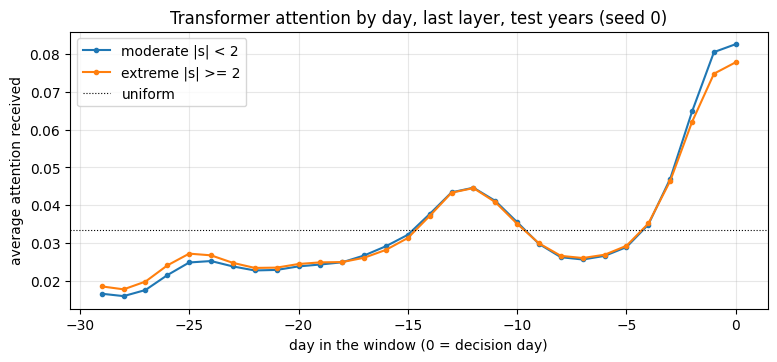

In [10]:
best_cfg = json.loads((runs / "best_transformer.json").read_text())["config"]
device = "cuda" if torch.cuda.is_available() else "cpu"
received = {"moderate |s| < 2": [], "extreme |s| >= 2": []}
for fold in make_folds(cfg["test_years"], cfg["train_start"], cfg["val_years"]):
    _, _, te = split(panel, fold, cfg["embargo_days"])
    model = build_model("transformer", best_cfg["lookback"], **best_cfg["params"]).to(device).eval()
    model.load_state_dict(torch.load(runs / "walkforward" / "test" / "models" / f"transformer_seed0_{fold.name}.pt",
                                     map_location=device))
    X = DayBlocks(panel, te, best_cfg["lookback"], device).X
    s_fold, _, ok_fold = ou_fit(panel.windows(te, cfg["window"]))
    ok_fold &= panel.tradable[te]
    flat_x = X[torch.from_numpy(ok_fold).to(device)]
    flat_s = np.abs(s_fold[ok_fold])
    with torch.no_grad():
        for a in range(0, len(flat_x), 4096):
            _, attn = model(flat_x[a:a + 4096].unsqueeze(-1), return_attn=True)
            got = attn[-1].mean(dim=(1, 2)).cpu().numpy()  # last layer: mean over heads and query days
            extreme = flat_s[a:a + 4096] >= 2
            received["moderate |s| < 2"].append(got[~extreme])
            received["extreme |s| >= 2"].append(got[extreme])

fig, ax = plt.subplots(figsize=(9, 3.6))
lags = np.arange(best_cfg["lookback"]) - best_cfg["lookback"] + 1
for label, parts in received.items():
    ax.plot(lags, np.concatenate(parts).mean(0), marker="o", ms=3, label=label)
ax.axhline(1 / best_cfg["lookback"], color="black", lw=0.8, ls=":", label="uniform")
ax.set_xlabel("day in the window (0 = decision day)")
ax.set_ylabel("average attention received")
ax.set_title("Transformer attention by day, last layer, test years (seed 0)")
ax.legend()
save(fig, "04_attention")
plt.show()

Attention concentrates on the last three days of the window, with a second peak about 12 days back and below-uniform weight on the oldest days. One reading: the model compares where the residual is now with where it was roughly one reversion half-life ago (the median half-life was 8.6 days). The pattern is the same for moderate and extreme stretches, so the model's different treatment of extreme moves comes from the values in the window, not from looking at different days.

## Takeaways

- **Verdict (pre-registered): no reliable edge after costs.** The Transformer earned +0.17 net Sharpe on 2020-2023 against OU's +0.15. PSR is 0.64, DSR 0.24, and the paired interval against OU spans -0.84 to +0.98, so none of the three rules passed.
- **Where the models do differ is robustness.** OU has the stronger raw signal (gross Sharpe 0.94 vs 0.51) but needs cheap, immediate execution. The Transformer trades a third less, so at 10 bps it makes -0.16 against OU's -0.65, at 20 bps -0.83 against -2.24, and with a one-day delay -0.03 against -0.44.
- **Costs in the loss help, consistently.** The cost-trained Transformer beat the identical cost-free one in all three seeds, trading less and earning more both gross and net.
- **One seed broke in one year.** Seed 0's 2023 model never improved on its starting point (best validation Sharpe -1.43 at epoch 0) and lost heavily (2023 Sharpe -3.44); the other two seeds earned about +0.35 that year. The protocol keeps every seed, so this stays in the result. A rule such as "don't trade a model whose validation Sharpe is negative" would be a sensible safeguard for future work, but adding it now would mean fitting to the test years.
- **Bottom line:** the learned models reproduce the classic signal, add a nonlinear twist that holds out of sample, and are far cheaper to run. But four years of S&P 500 data can't show that any of them earns more than the textbook OU rule after costs.